In [244]:
from scipy.io import arff
import pandas as pd
import os
import plotly.express as px
import numpy as np
import plotly.express as px
from scipy.stats import gaussian_kde

# 🔬 0. Import Data and initial inspection

In [3]:
data, met = arff.loadarff("emotions/emotions.arff")

In [4]:
df_emotions = pd.DataFrame(data)

In [5]:
df_emotions.head(20)

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
0,0.034741,0.089665,0.091225,-73.302422,6.215179,0.615074,2.037160,0.804065,1.301409,0.558576,...,2.0,0.245457,0.105065,0.405399,b'0',b'1',b'1',b'0',b'0',b'0'
1,0.081374,0.272747,0.085733,-62.584437,3.183163,-0.218145,0.163038,0.620251,0.458514,0.041426,...,2.0,0.343547,0.276366,0.710924,b'1',b'0',b'0',b'0',b'0',b'1'
2,0.110545,0.273567,0.084410,-65.235325,2.794964,0.639047,1.281297,0.757896,0.489412,0.627636,...,3.0,0.188693,0.045941,0.457372,b'0',b'1',b'0',b'0',b'0',b'1'
3,0.042481,0.199281,0.093447,-80.305152,5.824409,0.648848,1.754870,1.495532,0.739909,0.809644,...,2.0,0.102839,0.241934,0.351009,b'0',b'0',b'1',b'0',b'0',b'0'
4,0.074550,0.140880,0.079789,-93.697749,5.543229,1.064262,0.899152,0.890336,0.702328,0.490685,...,2.0,0.195196,0.310801,0.683817,b'0',b'0',b'0',b'1',b'0',b'0'
5,0.052434,0.110653,0.096770,-69.792637,6.598383,1.258462,2.873985,0.503222,0.782427,-0.143505,...,2.0,0.403684,0.245910,0.649594,b'0',b'1',b'1',b'0',b'0',b'0'
6,0.064067,0.147375,0.078124,-68.698041,4.052059,1.149220,2.063466,0.531396,0.877409,0.660980,...,2.0,0.755628,0.427281,1.182908,b'1',b'1',b'0',b'0',b'0',b'0'
7,0.044949,0.092085,0.097908,-68.406051,4.552287,0.898913,1.641708,1.490264,1.269593,0.884284,...,2.0,0.237070,0.087547,0.329783,b'0',b'0',b'0',b'0',b'0',b'1'
8,0.081354,0.302058,0.097240,-76.209068,2.419066,1.353814,1.681155,1.077603,1.078218,0.875479,...,2.0,1.131073,1.204185,2.335258,b'1',b'1',b'0',b'0',b'0',b'0'
9,0.039819,0.056986,0.073635,-83.146547,11.224703,1.280494,1.008498,0.940606,0.401406,0.008756,...,2.0,0.084776,0.137788,0.248702,b'0',b'0',b'1',b'1',b'1',b'0'


In [6]:
df_emotions.shape

(593, 78)

In [7]:
df_emotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593 entries, 0 to 592
Data columns (total 78 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Mean_Acc1298_Mean_Mem40_Centroid  593 non-null    float64
 1   Mean_Acc1298_Mean_Mem40_Rolloff   593 non-null    float64
 2   Mean_Acc1298_Mean_Mem40_Flux      593 non-null    float64
 3   Mean_Acc1298_Mean_Mem40_MFCC_0    593 non-null    float64
 4   Mean_Acc1298_Mean_Mem40_MFCC_1    593 non-null    float64
 5   Mean_Acc1298_Mean_Mem40_MFCC_2    593 non-null    float64
 6   Mean_Acc1298_Mean_Mem40_MFCC_3    593 non-null    float64
 7   Mean_Acc1298_Mean_Mem40_MFCC_4    593 non-null    float64
 8   Mean_Acc1298_Mean_Mem40_MFCC_5    593 non-null    float64
 9   Mean_Acc1298_Mean_Mem40_MFCC_6    593 non-null    float64
 10  Mean_Acc1298_Mean_Mem40_MFCC_7    593 non-null    float64
 11  Mean_Acc1298_Mean_Mem40_MFCC_8    593 non-null    float64
 12  Mean_Acc

In [81]:
df_emotions.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Mean_Acc1298_Mean_Mem40_Centroid,593.0,NaN,NaN,NaN,0.069309,0.031293,0.010201,0.044781,0.065251,0.08629,0.195412
Mean_Acc1298_Mean_Mem40_Rolloff,593.0,NaN,NaN,NaN,0.195399,0.117605,0.038286,0.107742,0.169757,0.257668,0.698277
Mean_Acc1298_Mean_Mem40_Flux,593.0,NaN,NaN,NaN,0.085695,0.00926,0.070932,0.079018,0.083637,0.091323,0.15946
Mean_Acc1298_Mean_Mem40_MFCC_0,593.0,NaN,NaN,NaN,-72.998228,7.580804,-99.090802,-77.078349,-72.474302,-68.292848,-56.297652
Mean_Acc1298_Mean_Mem40_MFCC_1,593.0,NaN,NaN,NaN,4.979178,2.071792,0.051474,3.409922,4.642338,6.439446,12.069754
...,...,...,...,...,...,...,...,...,...,...,...
happy-pleased,593,2,No,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relaxing-calm,593,2,No,329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quiet-still,593,2,No,445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sad-lonely,593,2,No,425,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_emotions.duplicated().sum()

0

In [10]:
df_emotions.isnull().sum()

Mean_Acc1298_Mean_Mem40_Centroid    0
Mean_Acc1298_Mean_Mem40_Rolloff     0
Mean_Acc1298_Mean_Mem40_Flux        0
Mean_Acc1298_Mean_Mem40_MFCC_0      0
Mean_Acc1298_Mean_Mem40_MFCC_1      0
                                   ..
happy-pleased                       0
relaxing-calm                       0
quiet-still                         0
sad-lonely                          0
angry-aggresive                     0
Length: 78, dtype: int64

# 🗺️ 1. EDA

In [12]:
type(df_emotions['happy-pleased'].iloc[0])

bytes

In [13]:
#change type of byte variables to string - Yes or No
emo_cols = [
    'amazed-suprised',
    'happy-pleased',
    'relaxing-calm',
    'quiet-still',
    'sad-lonely',
    'angry-aggresive'
]
    
for col in emo_cols:
    df_emotions[col] = df_emotions[col].str.decode('utf-8')

    df_emotions[col] = df_emotions[col].map(
        {'0': 'No',
        '1': 'Yes'}
    )
                                            


In [14]:
type(df_emotions['happy-pleased'].iloc[0])

str

In [15]:
df_emotions.head()

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
0,0.034741,0.089665,0.091225,-73.302422,6.215179,0.615074,2.037160,0.804065,1.301409,0.558576,...,2.0,0.245457,0.105065,0.405399,No,Yes,Yes,No,No,No
1,0.081374,0.272747,0.085733,-62.584437,3.183163,-0.218145,0.163038,0.620251,0.458514,0.041426,...,2.0,0.343547,0.276366,0.710924,Yes,No,No,No,No,Yes
2,0.110545,0.273567,0.084410,-65.235325,2.794964,0.639047,1.281297,0.757896,0.489412,0.627636,...,3.0,0.188693,0.045941,0.457372,No,Yes,No,No,No,Yes
3,0.042481,0.199281,0.093447,-80.305152,5.824409,0.648848,1.754870,1.495532,0.739909,0.809644,...,2.0,0.102839,0.241934,0.351009,No,No,Yes,No,No,No
4,0.074550,0.140880,0.079789,-93.697749,5.543229,1.064262,0.899152,0.890336,0.702328,0.490685,...,2.0,0.195196,0.310801,0.683817,No,No,No,Yes,No,No


In [16]:
df_emotions.columns

Index(['Mean_Acc1298_Mean_Mem40_Centroid', 'Mean_Acc1298_Mean_Mem40_Rolloff',
       'Mean_Acc1298_Mean_Mem40_Flux', 'Mean_Acc1298_Mean_Mem40_MFCC_0',
       'Mean_Acc1298_Mean_Mem40_MFCC_1', 'Mean_Acc1298_Mean_Mem40_MFCC_2',
       'Mean_Acc1298_Mean_Mem40_MFCC_3', 'Mean_Acc1298_Mean_Mem40_MFCC_4',
       'Mean_Acc1298_Mean_Mem40_MFCC_5', 'Mean_Acc1298_Mean_Mem40_MFCC_6',
       'Mean_Acc1298_Mean_Mem40_MFCC_7', 'Mean_Acc1298_Mean_Mem40_MFCC_8',
       'Mean_Acc1298_Mean_Mem40_MFCC_9', 'Mean_Acc1298_Mean_Mem40_MFCC_10',
       'Mean_Acc1298_Mean_Mem40_MFCC_11', 'Mean_Acc1298_Mean_Mem40_MFCC_12',
       'Mean_Acc1298_Std_Mem40_Centroid', 'Mean_Acc1298_Std_Mem40_Rolloff',
       'Mean_Acc1298_Std_Mem40_Flux', 'Mean_Acc1298_Std_Mem40_MFCC_0',
       'Mean_Acc1298_Std_Mem40_MFCC_1', 'Mean_Acc1298_Std_Mem40_MFCC_2',
       'Mean_Acc1298_Std_Mem40_MFCC_3', 'Mean_Acc1298_Std_Mem40_MFCC_4',
       'Mean_Acc1298_Std_Mem40_MFCC_5', 'Mean_Acc1298_Std_Mem40_MFCC_6',
       'Mean_Acc1298_Std_Mem40

### 🎯 1.1 CATEGORICAL VARIABLES - TARGETS

In [18]:
emo_counts = (
    df_emotions[emo_cols]
    .eq('Yes')
    .sum()
    .sort_values(ascending = False)
)

In [19]:
emo_counts

relaxing-calm      264
angry-aggresive    189
amazed-suprised    173
sad-lonely         168
happy-pleased      166
quiet-still        148
dtype: int64

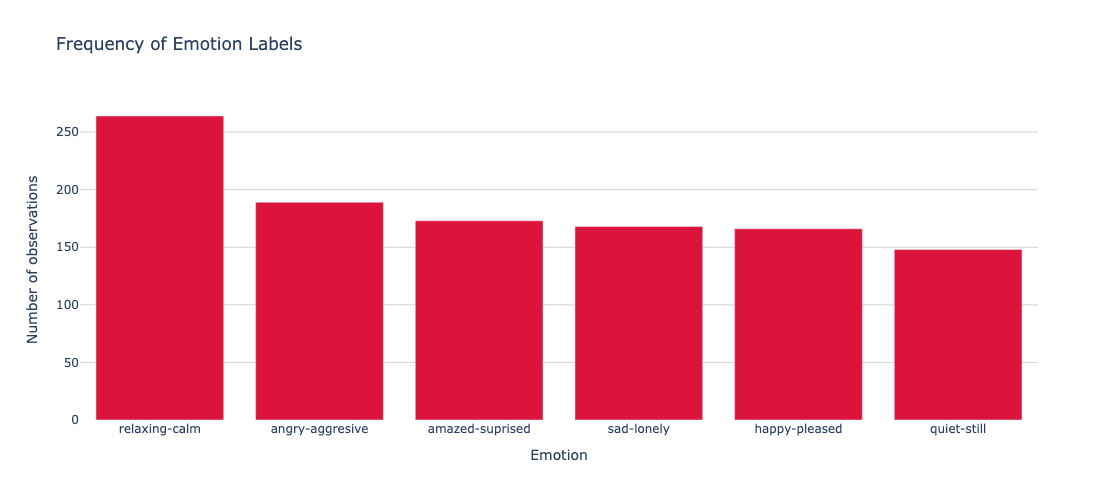

In [129]:
fig = px.bar(
    x=emo_counts.index,
    y=emo_counts.values,
    labels={
        'x': 'Emotion',
        'y': 'Number of observations'
    },
    title = 'Frequency of Emotion Labels',
    width=1100,
    height=500
    )
fig.update_traces(marker_color='crimson')
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_yaxes(
    showgrid=True,
    gridcolor='lightgray'
)
fig.show()

In [21]:
type(emo_cols)

list

In [22]:
emo_binary = (
    df_emotions[emo_cols]
    .replace({'No': 0, 'Yes': 1})
    .infer_objects(copy=False) #replace will be deprecated as it is, so this safeguards the old results
)

type(emo_binary)
emo_binary.head()

/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_87049/1439691792.py:3: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
0,0,1,1,0,0,0
1,1,0,0,0,0,1
2,0,1,0,0,0,1
3,0,0,1,0,0,0
4,0,0,0,1,0,0


In [23]:
#correlation
emo_corr = emo_binary.corr()
emo_corr

,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
amazed-suprised,1.000000,0.062565,-0.477873,-0.370126,-0.321184,0.293468
happy-pleased,0.062565,1.000000,0.129219,-0.298822,-0.383677,-0.329735
relaxing-calm,-0.477873,0.129219,1.000000,0.298812,0.152166,-0.561723
quiet-still,-0.370126,-0.298822,0.298812,1.000000,0.545410,-0.377725
sad-lonely,-0.321184,-0.383677,0.152166,0.545410,1.000000,-0.269406
angry-aggresive,0.293468,-0.329735,-0.561723,-0.377725,-0.269406,1.000000


In [24]:
#heatmap
fig = px.imshow(
    emo_corr,
    text_auto='.2f',
    zmin=-1,
    zmax=1,
    color_continuous_scale='mint',
    title='Relationships between emotion labels',
    width=1100,
    height=600
)

fig.show()

In [25]:
# how many labels a song receive
emo_yes = (
    df_emotions[emo_cols]
    .eq('Yes')
    .sum(axis=1) #axis 1 because we want to count across each row, not columns
)

type(emo_yes)

pandas.core.series.Series

In [26]:
emo_yes.value_counts().sort_index() 

# 178 songs have one label, 315 have 2 labels and 100 have 3 labels

1    178
2    315
3    100
Name: count, dtype: int64

In [27]:
# how the emotions appear together
emotion_combinations = []

for index, row in df_emotions[emo_cols].iterrows():
    emotions = []

    for col in emo_cols:
        if row[col] == 'Yes':
            emotions.append(col)

    emotion_combinations.append(' + '.join(emotions))

In [28]:
emotion_combinations

['happy-pleased + relaxing-calm',
 'amazed-suprised + angry-aggresive',
 'happy-pleased + angry-aggresive',
 'relaxing-calm',
 'quiet-still',
 'happy-pleased + relaxing-calm',
 'amazed-suprised + happy-pleased',
 'angry-aggresive',
 'amazed-suprised + happy-pleased',
 'relaxing-calm + quiet-still + sad-lonely',
 'happy-pleased + relaxing-calm',
 'relaxing-calm',
 'amazed-suprised',
 'relaxing-calm + sad-lonely',
 'sad-lonely',
 'amazed-suprised + angry-aggresive',
 'relaxing-calm + quiet-still + sad-lonely',
 'happy-pleased + relaxing-calm',
 'sad-lonely + angry-aggresive',
 'relaxing-calm + quiet-still + sad-lonely',
 'amazed-suprised + angry-aggresive',
 'happy-pleased',
 'happy-pleased',
 'angry-aggresive',
 'angry-aggresive',
 'relaxing-calm + angry-aggresive',
 'relaxing-calm',
 'amazed-suprised + happy-pleased + angry-aggresive',
 'happy-pleased',
 'relaxing-calm',
 'angry-aggresive',
 'relaxing-calm + quiet-still',
 'amazed-suprised + angry-aggresive',
 'angry-aggresive',
 'amaz

In [29]:
# count the combinations

combination_counts = pd.Series(
    emotion_combinations
).value_counts()

In [30]:
combination_counts

amazed-suprised + angry-aggresive                    81
happy-pleased + relaxing-calm                        74
angry-aggresive                                      72
relaxing-calm + quiet-still + sad-lonely             67
relaxing-calm                                        42
amazed-suprised + happy-pleased                      38
quiet-still + sad-lonely                             37
relaxing-calm + quiet-still                          30
relaxing-calm + sad-lonely                           25
amazed-suprised                                      24
happy-pleased                                        23
sad-lonely                                           12
sad-lonely + angry-aggresive                         12
amazed-suprised + happy-pleased + relaxing-calm      11
amazed-suprised + happy-pleased + angry-aggresive     7
amazed-suprised + sad-lonely                          6
happy-pleased + relaxing-calm + quiet-still           6
quiet-still                                     

In [31]:
fig = px.bar(
    x=combination_counts.values,
    y=combination_counts.index,
    orientation='h',
    labels={
        'x': 'Number of songs',
        'y': 'Emotion combination'
    },
    title='Emotion Combinations',
    width=1100,
    height=500
)

fig.show()

### 🎵 1.2 NUMERICAL VARIABLES 

In [33]:
num_cols = [
     'Mean_Acc1298_Mean_Mem40_Centroid',
     'Mean_Acc1298_Mean_Mem40_Rolloff',
     'Mean_Acc1298_Mean_Mem40_Flux',
     'Mean_Acc1298_Mean_Mem40_MFCC_0',
     'Mean_Acc1298_Mean_Mem40_MFCC_1',
     'Mean_Acc1298_Mean_Mem40_MFCC_2',
     'Mean_Acc1298_Mean_Mem40_MFCC_3',
     'Mean_Acc1298_Mean_Mem40_MFCC_4',
     'Mean_Acc1298_Mean_Mem40_MFCC_5',
     'Mean_Acc1298_Mean_Mem40_MFCC_6',
     'Mean_Acc1298_Mean_Mem40_MFCC_7',
     'Mean_Acc1298_Mean_Mem40_MFCC_8',
     'Mean_Acc1298_Mean_Mem40_MFCC_9',
     'Mean_Acc1298_Mean_Mem40_MFCC_10',
     'Mean_Acc1298_Mean_Mem40_MFCC_11',
     'Mean_Acc1298_Mean_Mem40_MFCC_12',
     'Mean_Acc1298_Std_Mem40_Centroid',
     'Mean_Acc1298_Std_Mem40_Rolloff',
     'Mean_Acc1298_Std_Mem40_Flux',
     'Mean_Acc1298_Std_Mem40_MFCC_0',
     'Mean_Acc1298_Std_Mem40_MFCC_1',
     'Mean_Acc1298_Std_Mem40_MFCC_2',
     'Mean_Acc1298_Std_Mem40_MFCC_3',
     'Mean_Acc1298_Std_Mem40_MFCC_4',
     'Mean_Acc1298_Std_Mem40_MFCC_5',
     'Mean_Acc1298_Std_Mem40_MFCC_6',
     'Mean_Acc1298_Std_Mem40_MFCC_7',
     'Mean_Acc1298_Std_Mem40_MFCC_8',
     'Mean_Acc1298_Std_Mem40_MFCC_9',
     'Mean_Acc1298_Std_Mem40_MFCC_10',
     'Mean_Acc1298_Std_Mem40_MFCC_11',
     'Mean_Acc1298_Std_Mem40_MFCC_12',
     'Std_Acc1298_Mean_Mem40_Centroid',
     'Std_Acc1298_Mean_Mem40_Rolloff',
     'Std_Acc1298_Mean_Mem40_Flux',
     'Std_Acc1298_Mean_Mem40_MFCC_0',
     'Std_Acc1298_Mean_Mem40_MFCC_1',
     'Std_Acc1298_Mean_Mem40_MFCC_2',
     'Std_Acc1298_Mean_Mem40_MFCC_3',
     'Std_Acc1298_Mean_Mem40_MFCC_4',
     'Std_Acc1298_Mean_Mem40_MFCC_5',
     'Std_Acc1298_Mean_Mem40_MFCC_6',
     'Std_Acc1298_Mean_Mem40_MFCC_7',
     'Std_Acc1298_Mean_Mem40_MFCC_8',
     'Std_Acc1298_Mean_Mem40_MFCC_9',
     'Std_Acc1298_Mean_Mem40_MFCC_10',
     'Std_Acc1298_Mean_Mem40_MFCC_11',
     'Std_Acc1298_Mean_Mem40_MFCC_12',
     'Std_Acc1298_Std_Mem40_Centroid',
     'Std_Acc1298_Std_Mem40_Rolloff',
     'Std_Acc1298_Std_Mem40_Flux',
     'Std_Acc1298_Std_Mem40_MFCC_0',
     'Std_Acc1298_Std_Mem40_MFCC_1',
     'Std_Acc1298_Std_Mem40_MFCC_2',
     'Std_Acc1298_Std_Mem40_MFCC_3',
     'Std_Acc1298_Std_Mem40_MFCC_4',
     'Std_Acc1298_Std_Mem40_MFCC_5',
     'Std_Acc1298_Std_Mem40_MFCC_6',
     'Std_Acc1298_Std_Mem40_MFCC_7',
     'Std_Acc1298_Std_Mem40_MFCC_8',
     'Std_Acc1298_Std_Mem40_MFCC_9',
     'Std_Acc1298_Std_Mem40_MFCC_10',
     'Std_Acc1298_Std_Mem40_MFCC_11',
     'Std_Acc1298_Std_Mem40_MFCC_12',
     'BH_LowPeakAmp',
     'BH_LowPeakBPM',
     'BH_HighPeakAmp',
     'BH_HighPeakBPM',
     'BH_HighLowRatio',
     'BHSUM1',
     'BHSUM2',
     'BHSUM3'
]

In [57]:
mm_cols = [
    'Mean_Acc1298_Mean_Mem40_Centroid',
    'Mean_Acc1298_Mean_Mem40_Rolloff',
    'Mean_Acc1298_Mean_Mem40_Flux',
    'Mean_Acc1298_Mean_Mem40_MFCC_0',
    'Mean_Acc1298_Mean_Mem40_MFCC_1',
    'Mean_Acc1298_Mean_Mem40_MFCC_2',
    'Mean_Acc1298_Mean_Mem40_MFCC_3',
    'Mean_Acc1298_Mean_Mem40_MFCC_4',
    'Mean_Acc1298_Mean_Mem40_MFCC_5',
    'Mean_Acc1298_Mean_Mem40_MFCC_6',
    'Mean_Acc1298_Mean_Mem40_MFCC_7',
    'Mean_Acc1298_Mean_Mem40_MFCC_8',
    'Mean_Acc1298_Mean_Mem40_MFCC_9',
    'Mean_Acc1298_Mean_Mem40_MFCC_10',
    'Mean_Acc1298_Mean_Mem40_MFCC_11',
    'Mean_Acc1298_Mean_Mem40_MFCC_12'
]

mstd_cols = [
    'Mean_Acc1298_Std_Mem40_Centroid',
    'Mean_Acc1298_Std_Mem40_Rolloff',
    'Mean_Acc1298_Std_Mem40_Flux',
    'Mean_Acc1298_Std_Mem40_MFCC_0',
    'Mean_Acc1298_Std_Mem40_MFCC_1',
    'Mean_Acc1298_Std_Mem40_MFCC_2',
    'Mean_Acc1298_Std_Mem40_MFCC_3',
    'Mean_Acc1298_Std_Mem40_MFCC_4',
    'Mean_Acc1298_Std_Mem40_MFCC_5',
    'Mean_Acc1298_Std_Mem40_MFCC_6',
    'Mean_Acc1298_Std_Mem40_MFCC_7',
    'Mean_Acc1298_Std_Mem40_MFCC_8',
    'Mean_Acc1298_Std_Mem40_MFCC_9',
    'Mean_Acc1298_Std_Mem40_MFCC_10',
    'Mean_Acc1298_Std_Mem40_MFCC_11',
    'Mean_Acc1298_Std_Mem40_MFCC_12'
]

stdm_cols = [
    'Std_Acc1298_Mean_Mem40_Centroid',
    'Std_Acc1298_Mean_Mem40_Rolloff',
    'Std_Acc1298_Mean_Mem40_Flux',
    'Std_Acc1298_Mean_Mem40_MFCC_0',
    'Std_Acc1298_Mean_Mem40_MFCC_1',
    'Std_Acc1298_Mean_Mem40_MFCC_2',
    'Std_Acc1298_Mean_Mem40_MFCC_3',
    'Std_Acc1298_Mean_Mem40_MFCC_4',
    'Std_Acc1298_Mean_Mem40_MFCC_5',
    'Std_Acc1298_Mean_Mem40_MFCC_6',
    'Std_Acc1298_Mean_Mem40_MFCC_7',
    'Std_Acc1298_Mean_Mem40_MFCC_8',
    'Std_Acc1298_Mean_Mem40_MFCC_9',
    'Std_Acc1298_Mean_Mem40_MFCC_10',
    'Std_Acc1298_Mean_Mem40_MFCC_11',
    'Std_Acc1298_Mean_Mem40_MFCC_12'
]

stdstd_cols = [
    'Std_Acc1298_Std_Mem40_Centroid',
    'Std_Acc1298_Std_Mem40_Rolloff',
    'Std_Acc1298_Std_Mem40_Flux',
    'Std_Acc1298_Std_Mem40_MFCC_0',
    'Std_Acc1298_Std_Mem40_MFCC_1',
    'Std_Acc1298_Std_Mem40_MFCC_2',
    'Std_Acc1298_Std_Mem40_MFCC_3',
    'Std_Acc1298_Std_Mem40_MFCC_4',
    'Std_Acc1298_Std_Mem40_MFCC_5',
    'Std_Acc1298_Std_Mem40_MFCC_6',
    'Std_Acc1298_Std_Mem40_MFCC_7',
    'Std_Acc1298_Std_Mem40_MFCC_8',
    'Std_Acc1298_Std_Mem40_MFCC_9',
    'Std_Acc1298_Std_Mem40_MFCC_10',
    'Std_Acc1298_Std_Mem40_MFCC_11',
    'Std_Acc1298_Std_Mem40_MFCC_12'
]

bh_cols = [
    'BH_LowPeakAmp',
    'BH_LowPeakBPM',
    'BH_HighPeakAmp',
    'BH_HighPeakBPM',
    'BH_HighLowRatio',
    'BHSUM1',
    'BHSUM2',
    'BHSUM3'
]

In [61]:
mean_mean = df_emotions[mm_cols]
mean_std = df_emotions[mstd_cols]
std_mean = df_emotions[stdm_cols]
std_std = df_emotions[stdstd_cols]
bh = df_emotions[bh_cols]

In [65]:
type(mean_mean)

pandas.core.frame.DataFrame

In [67]:
mm_cols

['Mean_Acc1298_Mean_Mem40_Centroid',
 'Mean_Acc1298_Mean_Mem40_Rolloff',
 'Mean_Acc1298_Mean_Mem40_Flux',
 'Mean_Acc1298_Mean_Mem40_MFCC_0',
 'Mean_Acc1298_Mean_Mem40_MFCC_1',
 'Mean_Acc1298_Mean_Mem40_MFCC_2',
 'Mean_Acc1298_Mean_Mem40_MFCC_3',
 'Mean_Acc1298_Mean_Mem40_MFCC_4',
 'Mean_Acc1298_Mean_Mem40_MFCC_5',
 'Mean_Acc1298_Mean_Mem40_MFCC_6',
 'Mean_Acc1298_Mean_Mem40_MFCC_7',
 'Mean_Acc1298_Mean_Mem40_MFCC_8',
 'Mean_Acc1298_Mean_Mem40_MFCC_9',
 'Mean_Acc1298_Mean_Mem40_MFCC_10',
 'Mean_Acc1298_Mean_Mem40_MFCC_11',
 'Mean_Acc1298_Mean_Mem40_MFCC_12']

In [79]:
mean_mean.describe().T

,count,mean,std,min,25%,50%,75%,max
Mean_Acc1298_Mean_Mem40_Centroid,593.0,0.069309,0.031293,0.010201,0.044781,0.065251,0.086290,0.195412
Mean_Acc1298_Mean_Mem40_Rolloff,593.0,0.195399,0.117605,0.038286,0.107742,0.169757,0.257668,0.698277
Mean_Acc1298_Mean_Mem40_Flux,593.0,0.085695,0.009260,0.070932,0.079018,0.083637,0.091323,0.159460
Mean_Acc1298_Mean_Mem40_MFCC_0,593.0,-72.998228,7.580804,-99.090802,-77.078349,-72.474302,-68.292848,-56.297652
Mean_Acc1298_Mean_Mem40_MFCC_1,593.0,4.979178,2.071792,0.051474,3.409922,4.642338,6.439446,12.069754
Mean_Acc1298_Mean_Mem40_MFCC_2,593.0,0.602395,1.017603,-2.277307,-0.113441,0.588380,1.293202,3.910873
Mean_Acc1298_Mean_Mem40_MFCC_3,593.0,1.694625,0.606581,-0.604609,1.307242,1.731031,2.072488,4.382370
Mean_Acc1298_Mean_Mem40_MFCC_4,593.0,0.634156,0.448746,-1.143864,0.373195,0.618838,0.925091,2.252710
Mean_Acc1298_Mean_Mem40_MFCC_5,593.0,0.833964,0.368312,-0.237114,0.605057,0.819652,1.051206,2.358098
Mean_Acc1298_Mean_Mem40_MFCC_6,593.0,0.508060,0.303277,-0.444623,0.309033,0.534665,0.708430,1.484489


In [87]:
mean_std.describe().T

,count,mean,std,min,25%,50%,75%,max
Mean_Acc1298_Std_Mem40_Centroid,593.0,0.045755,0.029710,0.006918,0.023090,0.037587,0.060700,0.168399
Mean_Acc1298_Std_Mem40_Rolloff,593.0,0.157495,0.108850,0.017434,0.064634,0.124873,0.241572,0.471795
Mean_Acc1298_Std_Mem40_Flux,593.0,0.035775,0.008561,0.025297,0.030011,0.033947,0.039220,0.116190
Mean_Acc1298_Std_Mem40_MFCC_0,593.0,4.574782,1.560977,1.665689,3.480119,4.449266,5.498476,15.262381
Mean_Acc1298_Std_Mem40_MFCC_1,593.0,1.298807,0.403095,0.544490,1.004433,1.266361,1.540143,3.664476
Mean_Acc1298_Std_Mem40_MFCC_2,593.0,0.941415,0.270601,0.426085,0.729514,0.928566,1.113193,2.045210
Mean_Acc1298_Std_Mem40_MFCC_3,593.0,0.778116,0.213410,0.436355,0.595706,0.735529,0.938902,1.491016
Mean_Acc1298_Std_Mem40_MFCC_4,593.0,0.650144,0.154363,0.343973,0.531264,0.625212,0.747990,1.321038
Mean_Acc1298_Std_Mem40_MFCC_5,593.0,0.577431,0.107429,0.376085,0.494993,0.557059,0.641188,1.016693
Mean_Acc1298_Std_Mem40_MFCC_6,593.0,0.552497,0.094156,0.329479,0.483637,0.541025,0.613560,0.825064


In [93]:
#define groups for analysis based on audio features
centroid_cols = [
    'Mean_Acc1298_Mean_Mem40_Centroid',
    'Mean_Acc1298_Std_Mem40_Centroid',
    'Std_Acc1298_Mean_Mem40_Centroid',
    'Std_Acc1298_Std_Mem40_Centroid'
]

rolloff_cols = [
    'Mean_Acc1298_Mean_Mem40_Rolloff',
    'Mean_Acc1298_Std_Mem40_Rolloff',
    'Std_Acc1298_Mean_Mem40_Rolloff',
    'Std_Acc1298_Std_Mem40_Rolloff'
]

flux_cols = [
    'Mean_Acc1298_Mean_Mem40_Flux',
    'Mean_Acc1298_Std_Mem40_Flux',
    'Std_Acc1298_Mean_Mem40_Flux',
    'Std_Acc1298_Std_Mem40_Flux'
]

mfcc_cols = [
    'Mean_Acc1298_Mean_Mem40_MFCC_0',
    'Mean_Acc1298_Mean_Mem40_MFCC_1',
    'Mean_Acc1298_Mean_Mem40_MFCC_2',
    'Mean_Acc1298_Mean_Mem40_MFCC_3',
    'Mean_Acc1298_Mean_Mem40_MFCC_4',
    'Mean_Acc1298_Mean_Mem40_MFCC_5',
    'Mean_Acc1298_Mean_Mem40_MFCC_6',
    'Mean_Acc1298_Mean_Mem40_MFCC_7',
    'Mean_Acc1298_Mean_Mem40_MFCC_8',
    'Mean_Acc1298_Mean_Mem40_MFCC_9',
    'Mean_Acc1298_Mean_Mem40_MFCC_10',
    'Mean_Acc1298_Mean_Mem40_MFCC_11',
    'Mean_Acc1298_Mean_Mem40_MFCC_12',
    'Mean_Acc1298_Std_Mem40_MFCC_0',
    'Mean_Acc1298_Std_Mem40_MFCC_1',
    'Mean_Acc1298_Std_Mem40_MFCC_2',
    'Mean_Acc1298_Std_Mem40_MFCC_3',
    'Mean_Acc1298_Std_Mem40_MFCC_4',
    'Mean_Acc1298_Std_Mem40_MFCC_5',
    'Mean_Acc1298_Std_Mem40_MFCC_6',
    'Mean_Acc1298_Std_Mem40_MFCC_7',
    'Mean_Acc1298_Std_Mem40_MFCC_8',
    'Mean_Acc1298_Std_Mem40_MFCC_9',
    'Mean_Acc1298_Std_Mem40_MFCC_10',
    'Mean_Acc1298_Std_Mem40_MFCC_11',
    'Mean_Acc1298_Std_Mem40_MFCC_12',
    'Std_Acc1298_Mean_Mem40_MFCC_0',
    'Std_Acc1298_Mean_Mem40_MFCC_1',
    'Std_Acc1298_Mean_Mem40_MFCC_2',
    'Std_Acc1298_Mean_Mem40_MFCC_3',
    'Std_Acc1298_Mean_Mem40_MFCC_4',
    'Std_Acc1298_Mean_Mem40_MFCC_5',
    'Std_Acc1298_Mean_Mem40_MFCC_6',
    'Std_Acc1298_Mean_Mem40_MFCC_7',
    'Std_Acc1298_Mean_Mem40_MFCC_8',
    'Std_Acc1298_Mean_Mem40_MFCC_9',
    'Std_Acc1298_Mean_Mem40_MFCC_10',
    'Std_Acc1298_Mean_Mem40_MFCC_11',
    'Std_Acc1298_Mean_Mem40_MFCC_12',
    'Std_Acc1298_Std_Mem40_MFCC_0',
    'Std_Acc1298_Std_Mem40_MFCC_1',
    'Std_Acc1298_Std_Mem40_MFCC_2',
    'Std_Acc1298_Std_Mem40_MFCC_3',
    'Std_Acc1298_Std_Mem40_MFCC_4',
    'Std_Acc1298_Std_Mem40_MFCC_5',
    'Std_Acc1298_Std_Mem40_MFCC_6',
    'Std_Acc1298_Std_Mem40_MFCC_7',
    'Std_Acc1298_Std_Mem40_MFCC_8',
    'Std_Acc1298_Std_Mem40_MFCC_9',
    'Std_Acc1298_Std_Mem40_MFCC_10',
    'Std_Acc1298_Std_Mem40_MFCC_11',
    'Std_Acc1298_Std_Mem40_MFCC_12'
]

In [97]:
centroid = df_emotions[centroid_cols]
rolloff = df_emotions[rolloff_cols]
flux = df_emotions[flux_cols]
mfcc = df_emotions[mfcc_cols]
bh = df_emotions[bh_cols]

In [111]:
centroid.head(20)

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Std_Mem40_Centroid,Std_Acc1298_Mean_Mem40_Centroid,Std_Acc1298_Std_Mem40_Centroid
0,0.034741,0.028851,0.013519,0.022774
1,0.081374,0.066288,0.013621,0.020028
2,0.110545,0.082743,0.029112,0.038119
3,0.042481,0.049939,0.020749,0.032678
4,0.074550,0.035751,0.047014,0.036151
5,0.052434,0.061100,0.017641,0.037052
6,0.064067,0.036757,0.019871,0.024036
7,0.044949,0.037329,0.021440,0.035572
8,0.081354,0.087255,0.018392,0.019922
9,0.039819,0.010135,0.014836,0.028101


#### 🎇 CENTROID

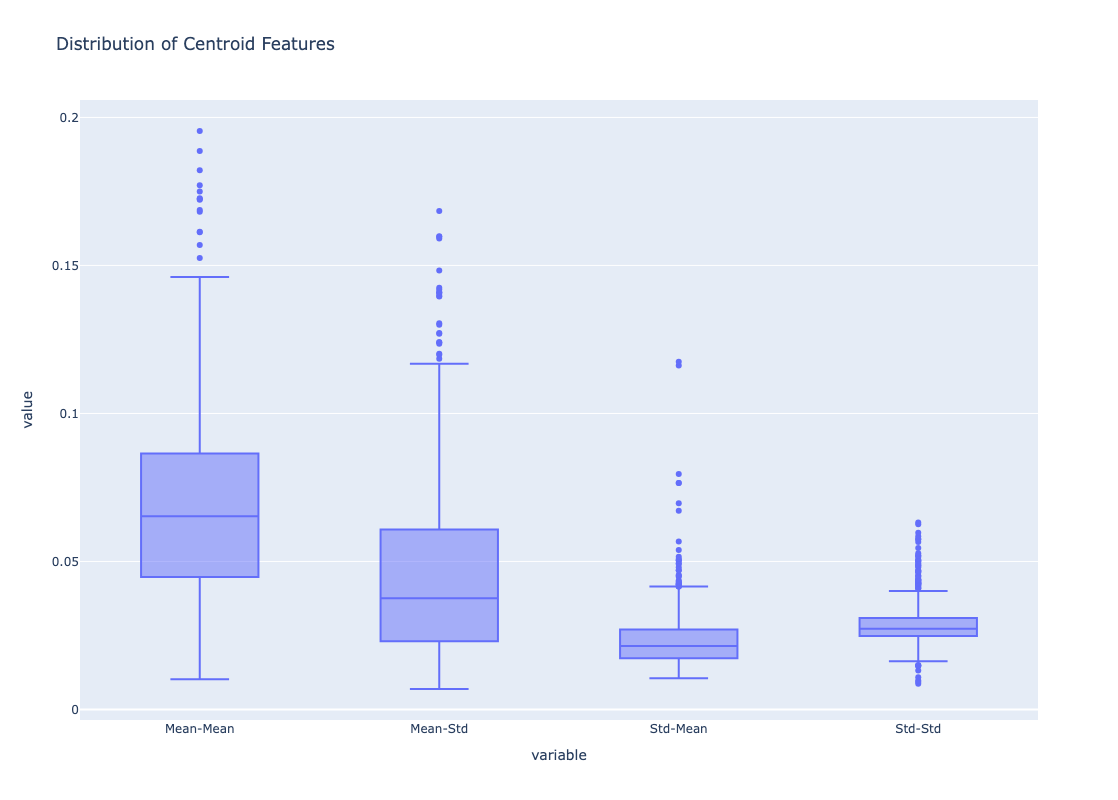

In [199]:
short_names = {
    centroid.columns[0]: 'Mean-Mean',
    centroid.columns[1]: 'Mean-Std',
    centroid.columns[2]: 'Std-Mean',
    centroid.columns[3]: 'Std-Std'
}

centroid_plot = centroid.rename(columns=short_names)


fig = px.box(
    centroid_plot,
    title='Distribution of Centroid Features',
    height=800
)

fig.show()

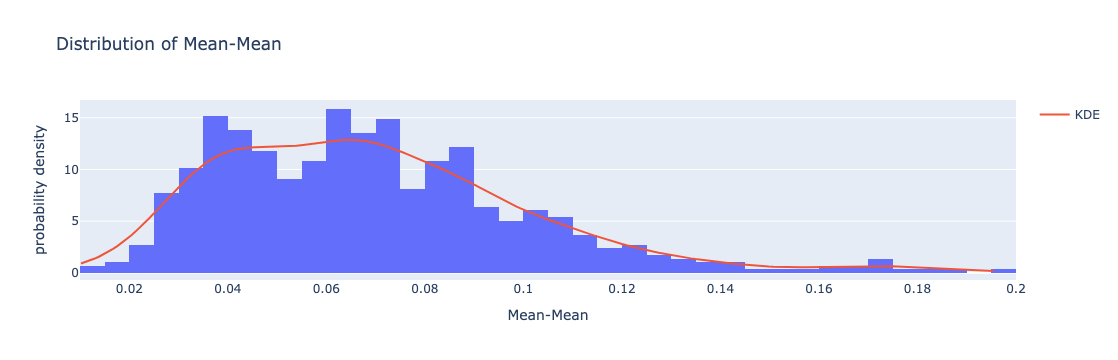

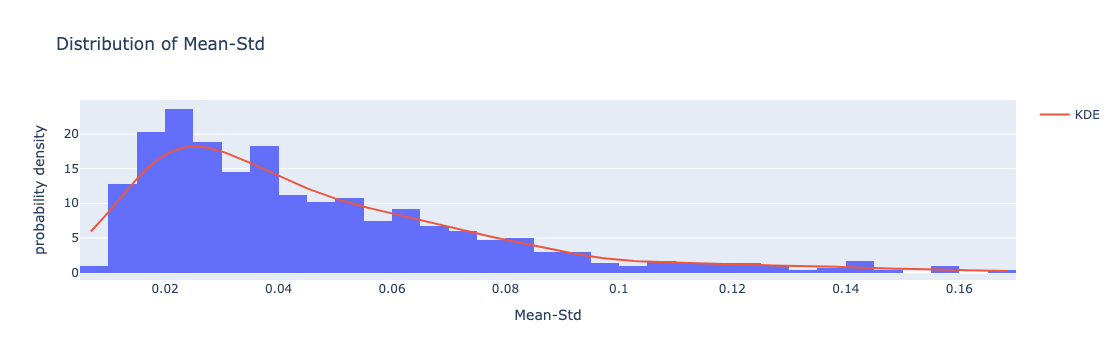

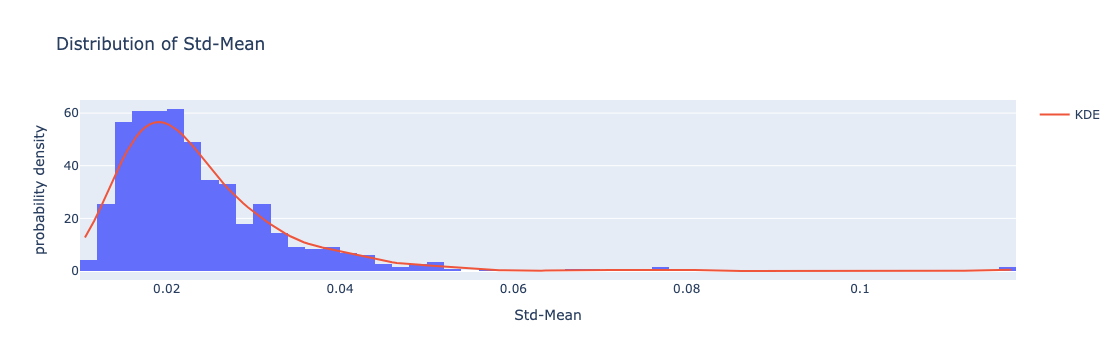

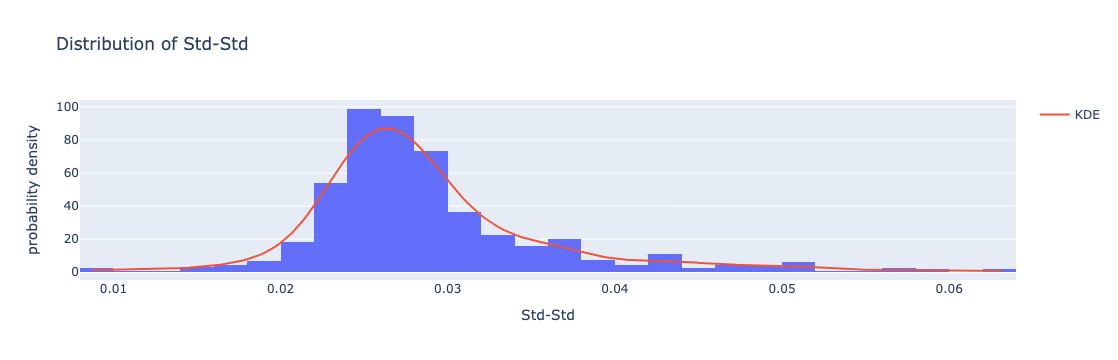

In [246]:
for col in centroid_plot.columns:
    
    values = centroid_plot[col].dropna()
    
    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 200)
    y = kde(x)

    fig = px.histogram(
        centroid_plot,
        x=col,
        title=f'Distribution of {col}',
        histnorm='probability density'
    )

    fig.add_scatter(
        x=x,
        y=y,
        mode='lines',
        name='KDE'
    )

    fig.show()

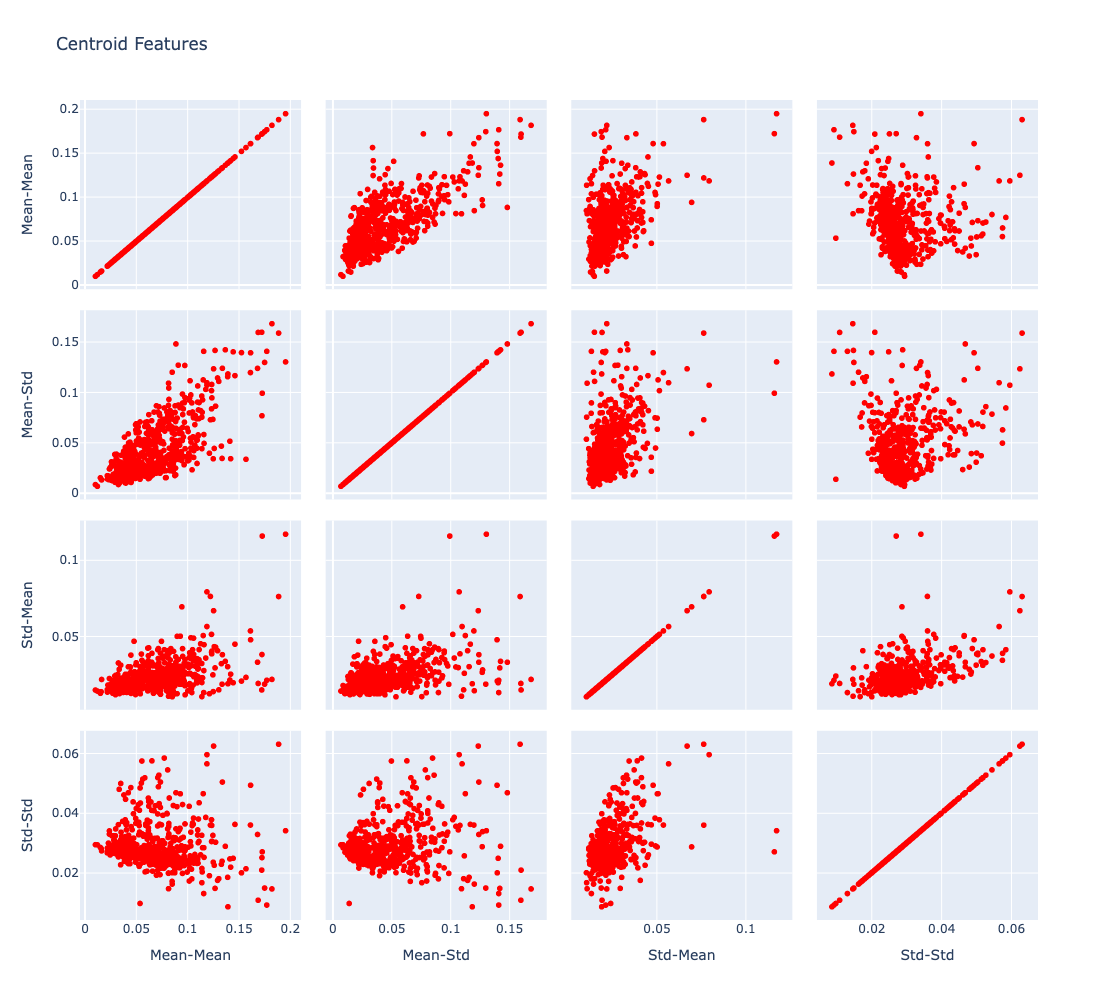

In [308]:
fig = px.scatter_matrix(
    centroid_plot,
    title='Centroid Features',
    height=1000,
    color_discrete_sequence=['red']
)

fig.show()

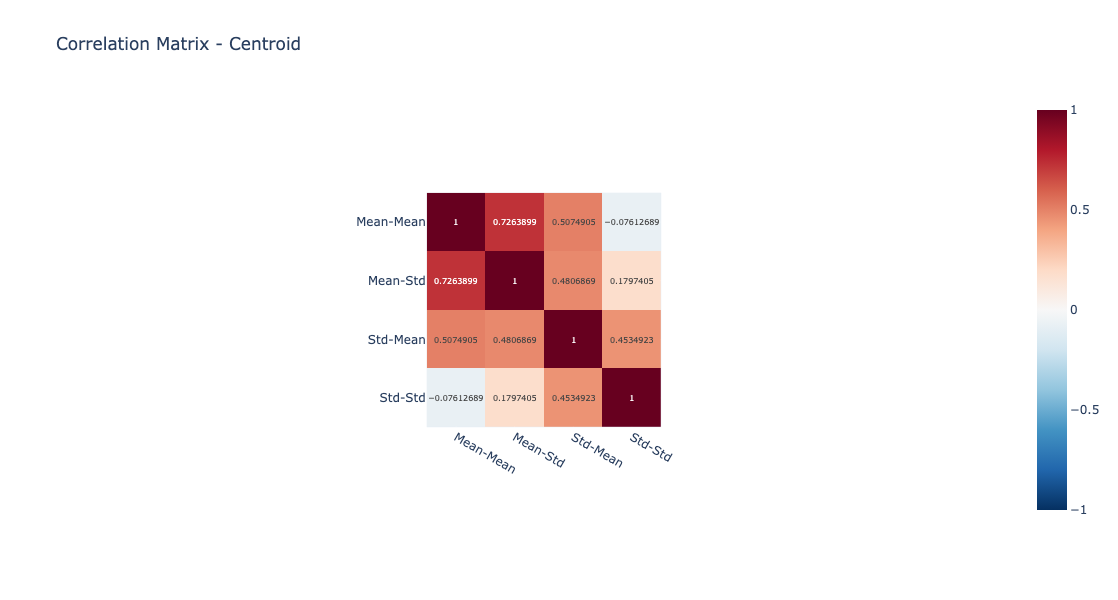

In [191]:
centroid_corr = centroid_plot.corr()

fig = px.imshow(
    centroid_corr,
    text_auto=True,
    title='Correlation Matrix - Centroid',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    height=600
)

fig.show()

In [227]:
# calculate outliers using the IQR rule

for col in centroid_plot.columns:
    Q1 = centroid_plot[col].quantile(0.25)
    Q3 = centroid_plot[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = centroid_plot[
    (centroid_plot[col] < lower_bound) |
    (centroid_plot[col] > upper_bound)
    ]

    print(col)
    print('Lower bound:', lower_bound)
    print('Upper bound:', upper_bound)
    print('Number of outliers:', len(outliers))
    print()

Mean-Mean
Lower bound: -0.017482500000000005
Upper bound: 0.1485535
Number of outliers: 14

Mean-Std
Lower bound: -0.033324999999999994
Upper bound: 0.117115
Number of outliers: 22

Std-Mean
Lower bound: 0.0029025000000000006
Upper bound: 0.0414345
Number of outliers: 32

Std-Std
Lower bound: 0.0156945
Upper bound: 0.0399945
Number of outliers: 56



In [231]:
outlier_summary = pd.DataFrame(
    columns=['Feature', 'Lower Bound', 'Upper Bound', 'Number of Outliers', 'Percentage of Outliers']
)

for col in centroid_plot.columns:
    Q1 = centroid_plot[col].quantile(0.25)
    Q3 = centroid_plot[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = centroid_plot[
        (centroid_plot[col] < lower_bound) |
        (centroid_plot[col] > upper_bound)
    ]
    
    new_row = pd.DataFrame({
        'Feature': [col],
        'Lower Bound': [lower_bound],
        'Upper Bound': [upper_bound],
        'Number of Outliers': [len(outliers)],
        'Percentage of Outliers': [len(outliers) / len(centroid) * 100]
    })
    
    outlier_summary = pd.concat(
        [outlier_summary, new_row],
        ignore_index=True
    )

outlier_summary

/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_87049/3127846081.py:27: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,Feature,Lower Bound,Upper Bound,Number of Outliers,Percentage of Outliers
0,Mean-Mean,-0.017483,0.148554,14,2.360877
1,Mean-Std,-0.033325,0.117115,22,3.709949
2,Std-Mean,0.002903,0.041434,32,5.396290
3,Std-Std,0.015695,0.039995,56,9.443508


#### 🎸 ROLLOFF

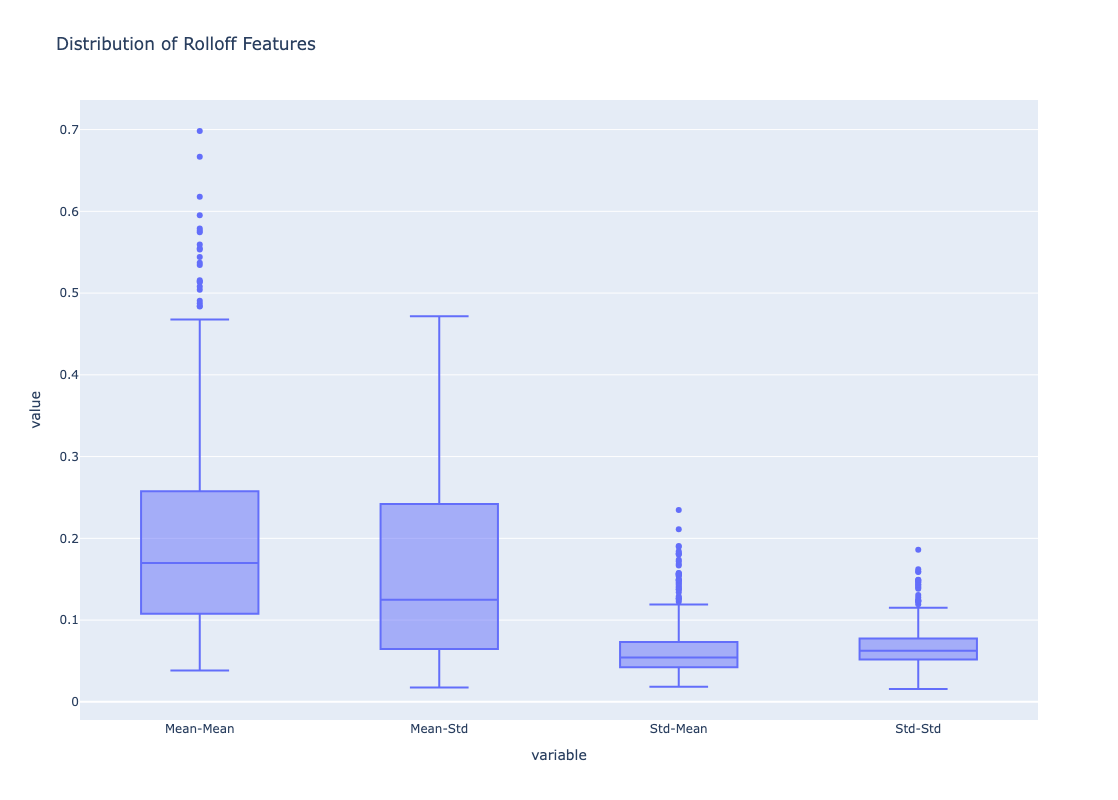

In [242]:
short_names = {
    rolloff.columns[0]: 'Mean-Mean',
    rolloff.columns[1]: 'Mean-Std',
    rolloff.columns[2]: 'Std-Mean',
    rolloff.columns[3]: 'Std-Std'
}

rolloff_plot = rolloff.rename(columns=short_names)


fig = px.box(
    rolloff_plot,
    title='Distribution of Rolloff Features',
    height=800
)

fig.show()

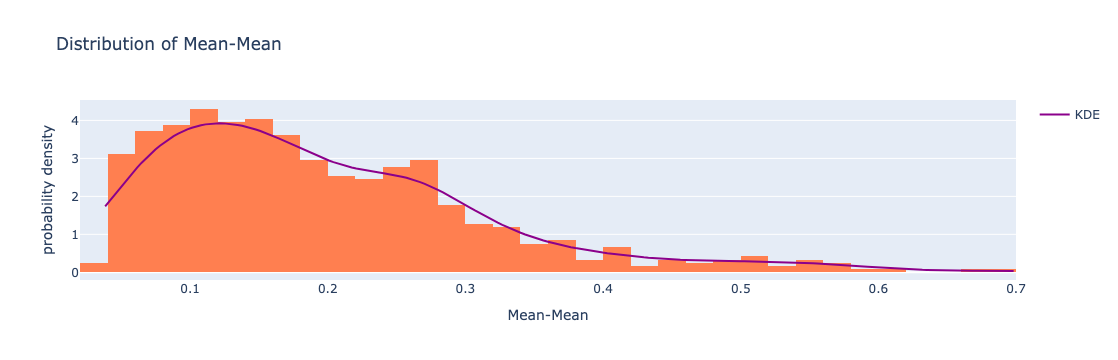

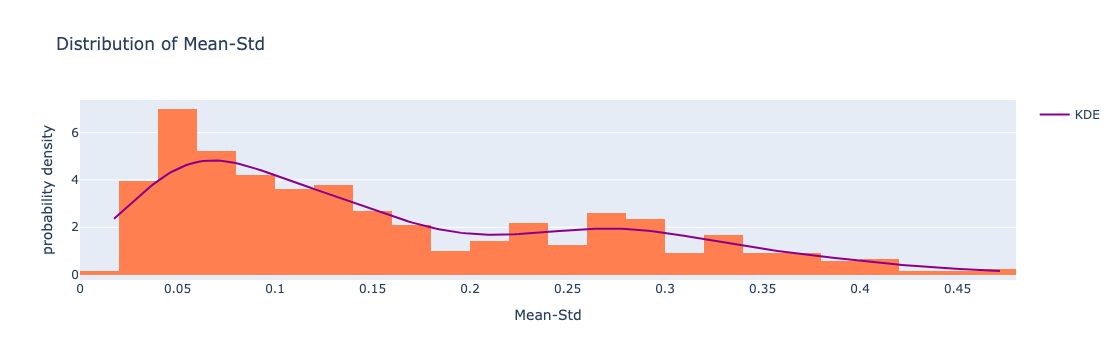

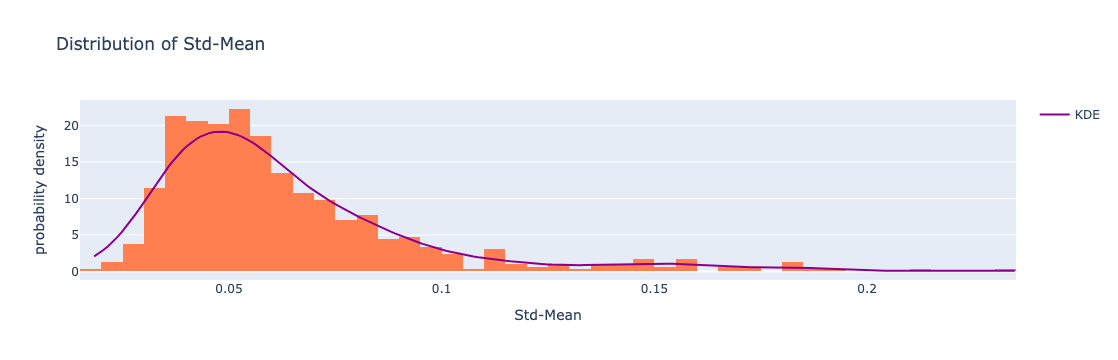

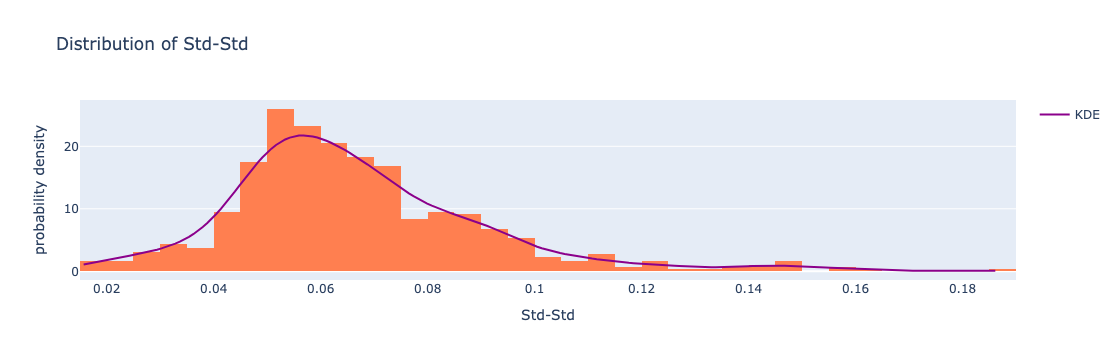

In [294]:
for col in rolloff_plot.columns:
    
    values = rolloff_plot[col].dropna()
    
    kde = gaussian_kde(values)
    x = np.linspace(values.min(), values.max(), 200)
    y = kde(x)

    fig = px.histogram(
        rolloff_plot,
        x=col,
        title=f'Distribution of {col}',
        histnorm='probability density',
        color_discrete_sequence=['coral']
    )

    fig.add_scatter(
        x=x,
        y=y,
        mode='lines',
        name='KDE',
        line=dict(color='darkmagenta')
    )

    fig.show()

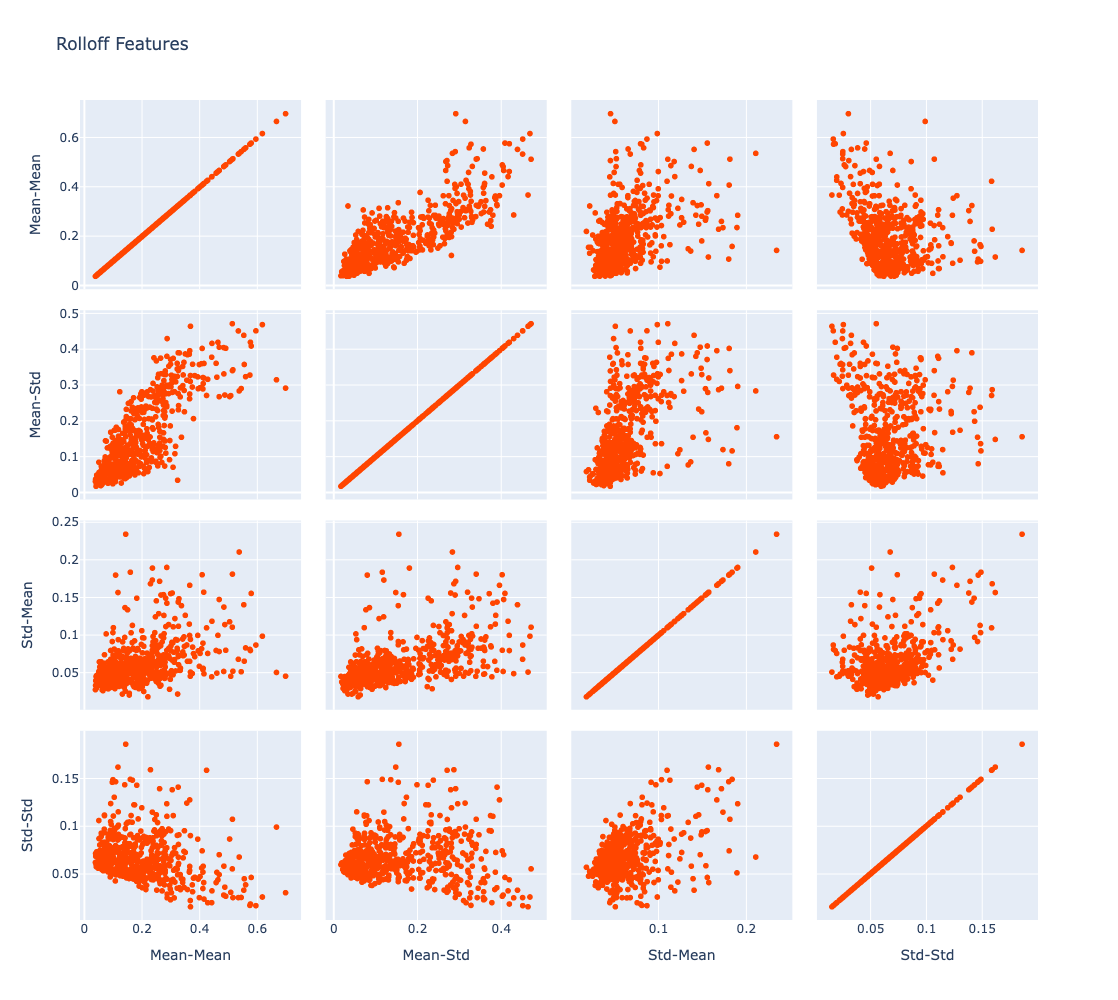

In [258]:
fig = px.scatter_matrix(
    rolloff_plot,
    title='Rolloff Features',
    height=1000,
    color_discrete_sequence=['orangered']
)

fig.show()

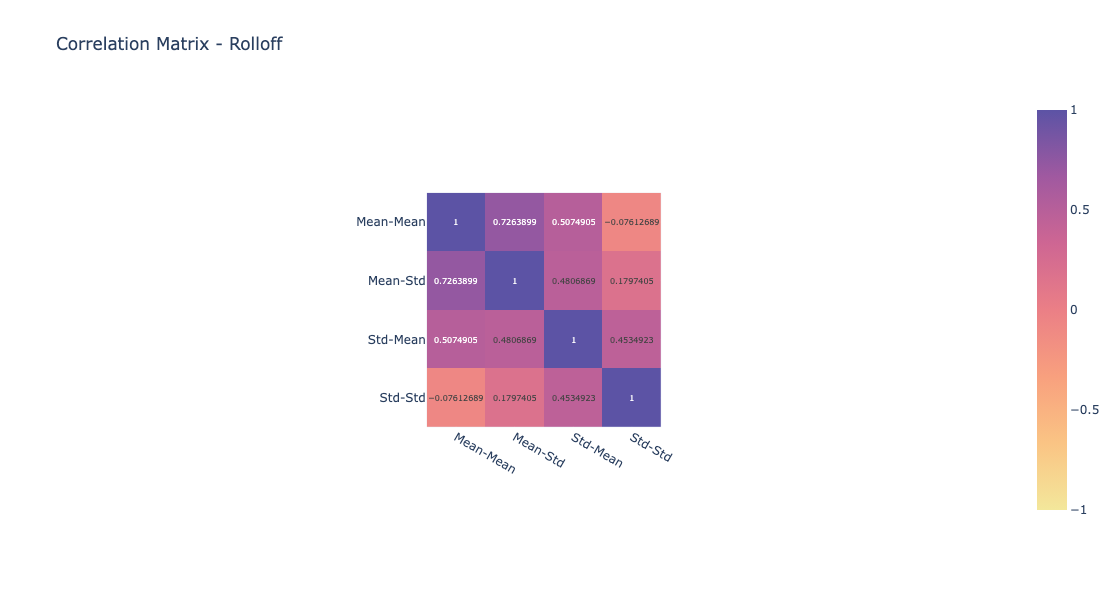

In [306]:
rolloff_corr = rolloff_plot.corr()

fig = px.imshow(
    centroid_corr,
    text_auto=True,
    title='Correlation Matrix - Rolloff',
    color_continuous_scale='sunset',
    zmin=-1,
    zmax=1,
    height=600
)

fig.show()

In [304]:
rolloff_plot_corr = rolloff_plot.corr()
rolloff_plot_corr

,Mean-Mean,Mean-Std,Std-Mean,Std-Std
Mean-Mean,1.000000,0.809104,0.446865,-0.246209
Mean-Std,0.809104,1.000000,0.544808,0.003200
Std-Mean,0.446865,0.544808,1.000000,0.481115
Std-Std,-0.246209,0.003200,0.481115,1.000000


In [310]:
# calculate outliers using the IQR rule

for col in rolloff_plot.columns:
    Q1 = rolloff_plot[col].quantile(0.25)
    Q3 = rolloff_plot[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = rolloff_plot[
    (rolloff_plot[col] < lower_bound) |
    (rolloff_plot[col] > upper_bound)
    ]

    print(col)
    print('Lower bound:', lower_bound)
    print('Upper bound:', upper_bound)
    print('Number of outliers:', len(outliers))
    print()

Mean-Mean
Lower bound: -0.117147
Upper bound: 0.482557
Number of outliers: 22

Mean-Std
Lower bound: -0.200773
Upper bound: 0.5069790000000001
Number of outliers: 0

Std-Mean
Lower bound: -0.0037064999999999945
Upper bound: 0.11908949999999999
Number of outliers: 36

Std-Std
Lower bound: 0.0129255
Upper bound: 0.11634549999999999
Number of outliers: 22



#### 🔉 FLUX

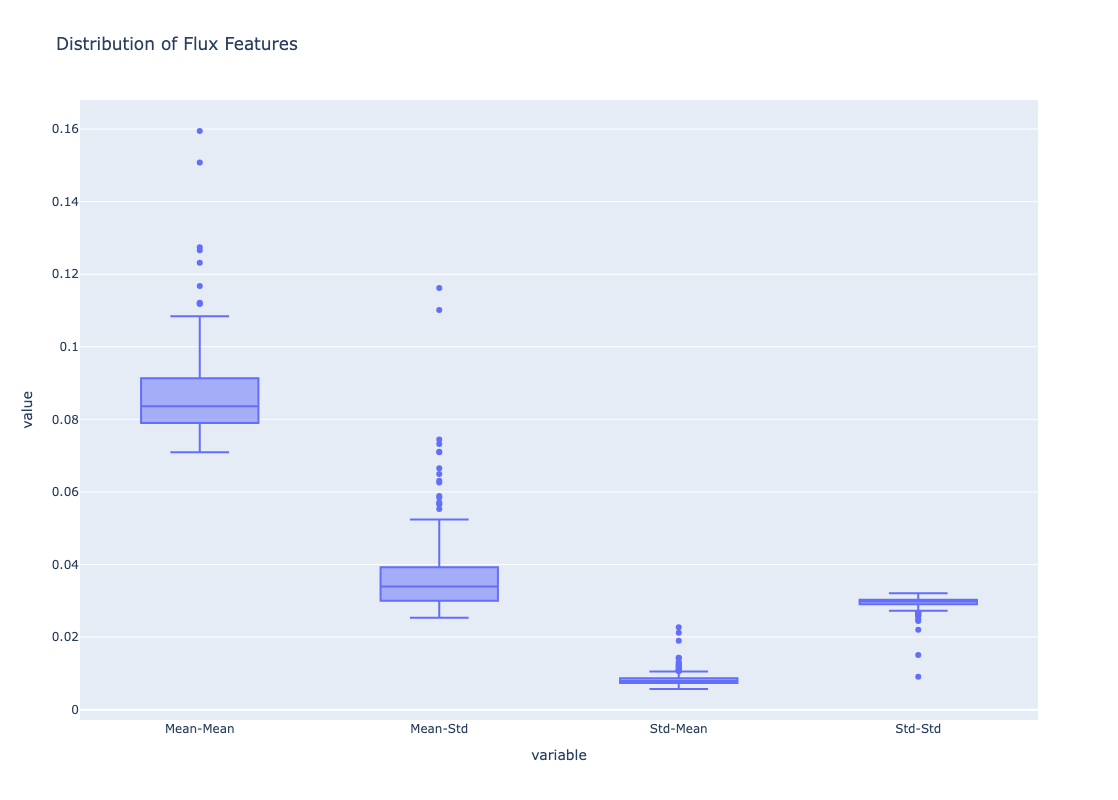

In [314]:
short_names = {
    flux.columns[0]: 'Mean-Mean',
    flux.columns[1]: 'Mean-Std',
    flux.columns[2]: 'Std-Mean',
    flux.columns[3]: 'Std-Std'
}

flux_plot = flux.rename(columns=short_names)


fig = px.box(
    flux_plot,
    title='Distribution of Flux Features',
    height=800
)

fig.show()